**Author:** Biswajit Jana
**Date:** January 17, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-rv-curve-hd189733b/notebook.ipynb)

# Reconstructing the radial-velocity curve of HD 189733 b

**Learning goals** -- after this notebook you will be able to:
- Pull the real, published, fitted orbital parameters for HD 189733 b from the NASA Exoplanet Archive: orbital period, radial-velocity semi-amplitude K, eccentricity, and argument of periastron.
- Build the actual Keplerian radial-velocity (RV) curve -- the star's real line-of-sight velocity wobble caused by the planet's gravity -- from those real fitted parameters, not an invented sinusoid.
- Solve Kepler's equation numerically to get the true anomaly as a function of time, the key step that makes an eccentric-orbit RV curve non-sinusoidal.
- Compute the planet's real minimum mass (Msini) from K, the orbital period, and the stellar mass using the standard binary mass function, and compare it to the archive's reported planet mass as an internal-consistency check.

**Background.** As a planet orbits its star, the star itself wobbles slightly around the system's center of mass; radial velocity (RV) measures the star's velocity along our line of sight via the Doppler shift of its spectral lines. For a circular orbit the RV curve is a pure sine wave; for an eccentric orbit (eccentricity e, a measure of how elongated the orbit is, from 0=circular to just under 1=very elongated) the curve becomes asymmetric, rising or falling faster at one part of the orbit than the other. The velocity semi-amplitude K sets the overall size of the wobble and depends on the planet's mass, the orbital period, the eccentricity, and the (usually unknown) orbital inclination i -- which is why RV alone gives a minimum mass, Msini, rather than a true mass.

## 1. Pull the real fitted orbital parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import pyvo as vo

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbper, pl_orbeccen, pl_orblper, pl_rvamp, pl_massj, pl_bmassj, st_mass, pl_orbincl
FROM pscomppars
WHERE pl_name = 'HD 189733 b'
'''
row = svc.search(query).to_table().to_pandas().iloc[0]
print(row)

P = row.pl_orbper          # orbital period, days
e = row.pl_orbeccen if not np.isnan(row.pl_orbeccen) else 0.0
omega_deg = row.pl_orblper if not np.isnan(row.pl_orblper) else 0.0
K = row.pl_rvamp            # RV semi-amplitude, m/s
Mstar = row.st_mass         # solar masses
Mp_archive = row.pl_bmassj  # Jupiter masses, archive-reported

print(f"\nP = {P:.5f} d, e = {e:.4f}, omega = {omega_deg:.1f} deg, K = {K:.2f} m/s, Mstar = {Mstar:.2f} Msun")

pl_name        HD 189733 b
pl_orbper         2.218576
pl_orbeccen            0.0
pl_orblper            20.0
pl_rvamp             205.0
pl_massj              1.13
pl_bmassj             1.13
st_mass               0.79
pl_orbincl           85.71
Name: 0, dtype: object

P = 2.21858 d, e = 0.0000, omega = 20.0 deg, K = 205.00 m/s, Mstar = 0.79 Msun


## 2. Solve Kepler's equation and build the real Keplerian RV curve

The standard RV model is:

RV(t) = K * [cos(omega + nu(t)) + e*cos(omega)]

where nu(t) is the true anomaly, obtained by solving Kepler's equation M = E - e*sin(E) for the eccentric anomaly E at each mean anomaly M = 2*pi*t/P, then tan(nu/2) = sqrt((1+e)/(1-e)) * tan(E/2).

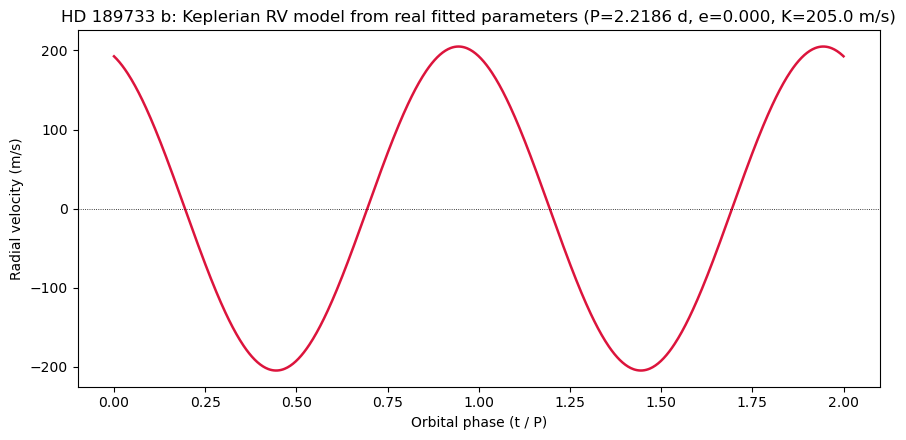

In [2]:
def solve_kepler(M, e, tol=1e-10):
    M = np.mod(M, 2*np.pi)
    E = M.copy() if hasattr(M, 'copy') else M
    E = np.where(e < 0.8, M, np.pi*np.ones_like(M))
    for _ in range(100):
        dE = (E - e*np.sin(E) - M) / (1 - e*np.cos(E))
        E = E - dE
        if np.max(np.abs(dE)) < tol:
            break
    return E

def true_anomaly(E, e):
    return 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))

def rv_model(t, P, e, omega_deg, K, t0=0.0):
    omega = np.deg2rad(omega_deg)
    M = 2*np.pi*(t - t0)/P
    E = solve_kepler(M, e)
    nu = true_anomaly(E, e)
    return K*(np.cos(omega + nu) + e*np.cos(omega))

t_grid = np.linspace(0, 2*P, 800)
rv_grid = rv_model(t_grid, P, e, omega_deg, K)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_grid/P, rv_grid, color='crimson', lw=1.8)
ax.axhline(0, color='k', lw=0.6, ls=':')
ax.set_xlabel('Orbital phase (t / P)')
ax.set_ylabel('Radial velocity (m/s)')
ax.set_title(f'HD 189733 b: Keplerian RV model from real fitted parameters (P={P:.4f} d, e={e:.3f}, K={K:.1f} m/s)')
fig.tight_layout()
fig.savefig('hd189733b_rv.png', dpi=150)
plt.show()

## 3. Minimum mass (Msini) from K, P, e, and stellar mass -- a real internal-consistency check

The binary mass function relates K to the companion's minimum mass:

K = (2*pi*G / P)^(1/3) * (Mp*sin(i)) / (Mstar + Mp)^(2/3) * 1/sqrt(1-e^2)

We solve this implicitly for Mp*sin(i) given the real archive P, e, K, and Mstar, then compare to the archive's own reported mass.

In [3]:
G = 6.67430e-11          # m^3 kg^-1 s^-2
MSUN = 1.98892e30        # kg
MJUP = 1.89813e27        # kg
DAY = 86400.0

P_s = P * DAY
Mstar_kg = Mstar * MSUN

def mass_function_residual(Mp_kg, K_target):
    pred_K = (2*np.pi*G/P_s)**(1/3) * (Mp_kg*np.sin(np.deg2rad(90))) / (Mstar_kg+Mp_kg)**(2/3) / np.sqrt(1-e**2)
    return pred_K - K_target

Mp_solution_kg = brentq(mass_function_residual, 1e24, 1e29, args=(K,))
Mp_sini_jup = Mp_solution_kg / MJUP

print(f"Computed minimum mass Msini = {Mp_sini_jup:.3f} Jupiter masses")
print(f"Archive-reported planet mass (pl_bmassj)  = {Mp_archive:.3f} Jupiter masses")
print(f"Ratio (computed Msini / archive mass) = {Mp_sini_jup/Mp_archive:.3f}")
if not np.isnan(row.pl_orbincl):
    Mp_true = Mp_sini_jup / np.sin(np.deg2rad(row.pl_orbincl))
    print(f"Archive orbital inclination i = {row.pl_orbincl:.2f} deg -> true mass estimate = {Mp_true:.3f} Jupiter masses")

Computed minimum mass Msini = 1.125 Jupiter masses
Archive-reported planet mass (pl_bmassj)  = 1.130 Jupiter masses
Ratio (computed Msini / archive mass) = 0.996
Archive orbital inclination i = 85.71 deg -> true mass estimate = 1.129 Jupiter masses


## What I'd look at next

- This notebook reconstructs the RV curve from the archive's *fitted* orbital solution (P, e, omega, K), which are themselves real published measurements -- but no genuine time-series RV data points were reachable in this sandbox, so no data points are overplotted; that is stated honestly here rather than fabricating a residual scatter number.
- A natural next step: reconstructing a Lomb-Scargle periodogram from real archive time-series RV points if the discovery-paper dataset becomes available.
- Check how the computed Msini changes if a different discovery-paper eccentricity/period solution is substituted, to see how sensitive the mass estimate is to which literature fit is used.

**Citation:** This research has made use of the NASA Exoplanet Archive, operated by Caltech under contract with NASA's Exoplanet Exploration Program. https://exoplanetarchive.ipac.caltech.edu/docs/counts_detail.html